<a name="intro"></a>
# An **interpretable KAN Regressor**
**Task**: predict the per-bin expected probability distribution of photon counts, combining temporal information with satellite info/metadata (e.g., coordinates, altitudes, position), verifying whether the predicted distribution aligns with the theoretical or expected probability distribution.

## **Importing** libraries

In [99]:
import sys
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Internship + Thesis')

Mounted at /content/drive


In [100]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import math
import importlib
from scipy.signal import find_peaks
from statsmodels.tsa.stattools import acf

from utils.viz_utils import *

In [102]:
# reload to stay updated with changes
from utils import viz_utils
importlib.reload(viz_utils)

<module 'utils.viz_utils' from '/content/drive/MyDrive/Colab Notebooks/Internship + Thesis/utils/viz_utils.py'>

In [103]:
# defining paths
data_path = "/content/drive/MyDrive/Colab Notebooks/Internship + Thesis/src/data"

## **Inspecting** the data
Let's import our orientation dataframe, that will mainly contain satellite metadata.

In [104]:
# Loading dataset and printing shape
satellite_data_original = pd.read_excel(os.path.join(data_path, "satellite_data_mod.xlsx"))
print(f"Satellite dataset shape: {satellite_data_original.shape}")

Satellite dataset shape: (5761, 9)


In [105]:
satellite_data_original.head()

,TypeOrientationsGalactic,timestamp,x_lat,x_lon,z_lat,z_lon(galactic),altitude(km),Earth_lat,Earth_lon
0,OG,1.835487e+09,59.274529,22.415898,-30.725471,22.415898,530.222097,-0.000190,27.047042
1,OG,1.835487e+09,58.504010,22.732337,-31.495990,22.732337,530.219997,-0.000184,27.927215
2,OG,1.835487e+09,57.732736,23.048787,-32.267264,23.048787,530.216960,-0.000177,28.807377
3,OG,1.835487e+09,56.960731,23.365378,-33.039269,23.365378,530.212986,-0.000171,29.687529
4,OG,1.835487e+09,56.188017,23.682244,-33.811983,23.682244,530.208077,-0.000165,30.567670


In [106]:
satellite_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5761 entries, 0 to 5760
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TypeOrientationsGalactic  5761 non-null   object 
 1   timestamp                 5761 non-null   float64
 2   x_lat                     5761 non-null   float64
 3   x_lon                     5761 non-null   float64
 4   z_lat                     5761 non-null   float64
 5   z_lon(galactic)           5761 non-null   float64
 6   altitude(km)              5761 non-null   float64
 7   Earth_lat                 5761 non-null   float64
 8   Earth_lon                 5761 non-null   float64
dtypes: float64(8), object(1)
memory usage: 405.2+ KB


We can drop the Type of Orientations Galactic column, since it does not provide useful information.

In [107]:
satellite_data_original = satellite_data_original.drop(columns=['TypeOrientationsGalactic'])
satellite_data_original.rename(columns={'z_lon(galactic)':'z_lon'}, inplace=True)
input_features = satellite_data_original.columns.drop(['timestamp'])
print(f"Input features: {input_features}")

Input features: Index(['x_lat', 'x_lon', 'z_lat', 'z_lon', 'altitude(km)', 'Earth_lat',
       'Earth_lon'],
      dtype='object')


In [108]:
# overall description
satellite_data_original.describe()

,timestamp,x_lat,x_lon,z_lat,z_lon,altitude(km),Earth_lat,Earth_lon
count,5.761000e+03,5761.000000,5761.000000,5761.000000,5761.000000,5761.000000,5761.000000,5761.000000
mean,1.835530e+09,54.089440,122.407505,-0.245103,157.370185,526.798419,-0.000162,179.255362
std,2.494803e+04,22.704842,75.078192,42.488139,103.711938,2.445737,0.000121,104.154585
min,1.835487e+09,5.251886,8.181763,-84.744034,0.005977,523.323590,-0.000412,0.003675
25%,1.835509e+09,41.281750,53.891935,-34.585383,50.056662,524.359281,-0.000256,88.627557
50%,1.835530e+09,55.819180,121.732866,-0.369437,179.006845,526.830513,-0.000167,178.995223
75%,1.835552e+09,71.944084,188.336870,33.814511,230.402957,529.248357,-0.000080,269.486623
max,1.835574e+09,89.995229,237.654764,84.748114,359.910660,530.223516,0.000122,359.949445


> We spot that `z_lon` and `Earth_lon` are **periodic** variables, because they range in the interval `[0, 360]`.

Visualizing columns

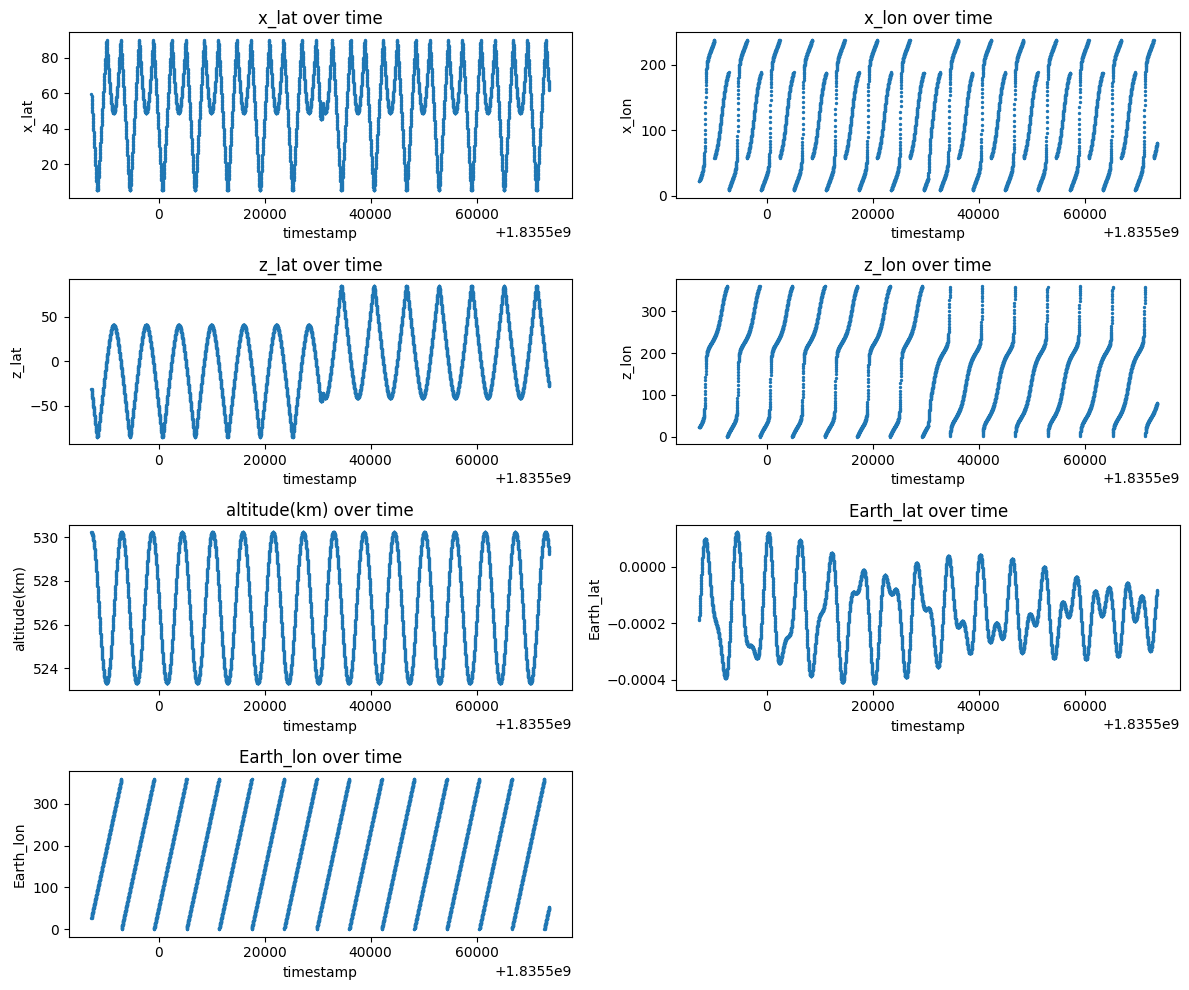

In [109]:
viz_df_cols(satellite_data_original, cols_to_plot=input_features)

> We can easily spot how all of the feature columns show some kind of obscillatory pattern, due to the satellite **orbit motion**, that repeats itself every *N* timestamps.

#### Feature explanation

The columns of the orientation dataframe constitute the input features of our regressor. It is therefore useful to clarify their physical meaning. The x and z coordinates describe the orientation (attitude) of the spacecraft, i.e., the pointing directions of two of its body axes. The +X axis is a lateral axis defined by the mechanical structure of the spacecraft, while the +Z axis corresponds to the main primary pointing direction of the satellite (the boresight).

- **x_lat / x_lon:** latitude and longitude of the spacecraft’s +X axis direction, expressed in an Earth-centered celestial reference frame.
- **z_lat / z_lon:** latitude and longitude of the spacecraft’s +Z axis, i.e., the main pointing direction (boresight) projected in the same reference frame.
- **altitude**: the orbital altitude (in km) of the satellite above Earth’s surface.
- **Earth_lat / Earth_lon**: geographic latitude and longitude of the satellite’s sub-satellite point, i.e., the point on Earth directly underneath the spacecraft at each instant. These coordinates describe the satellite’s position along its orbit, independent of its pointing direction.


Loading other data

In [110]:
# Loading time and rate arrays for different time res.
time_array_15s = np.load(os.path.join(data_path, "time_array.npy"))     # 15s
total_counts_15s = np.load(os.path.join(data_path, 'total_counts.npy'))
total_rates_15s = np.load(os.path.join(data_path, 'total_rates.npy'))

time_array_50ms = np.load(os.path.join(data_path, 'total_time_50ms.npy'))
total_counts_50ms = np.load(os.path.join(data_path, 'total_counts_50ms.npy'))
total_rates_50ms = np.load(os.path.join(data_path, 'total_rates_50ms.npy'))

time_array_1s = np.load(os.path.join(data_path, 'total_time_1s.npy'))
total_counts_1s = np.load(os.path.join(data_path, 'total_counts_1s.npy'))
total_rates_1s = np.load(os.path.join(data_path, 'total_rates_1s.npy'))

Here, `total_rates` contains the rates for each of the 6 detectors with 15s bins, while `time_array` contains the time associated with the rates

The *i-th* element of the rate array is aligned with the *i-th* element of the time array.

In [111]:
print(f"15s arrays:\nCount rates shape: {total_rates_15s.shape}") #contains the GRB rates for each of the 6 detectors with 15s bins
print(f"Counts shape: {time_array_15s.shape}") #contains the GRB counts for each of the 6 detectors
print(f"Timesteps array shape: {time_array_15s.shape}") #contains the time associated with the rates

print(f"\n50ms arrays:\nCount rates shape: {total_rates_50ms.shape}") #contains the GRB rates for each of the 6 detectors with 50ms bins
print(f"Counts shape: {time_array_50ms.shape}")
print(f"Timesteps array shape: {time_array_50ms.shape}")

print(f"\n1s arrays:\nCount rates shape: {total_rates_1s.shape}") #contains the GRB rates for each of the 6 detectors with 1s bins
print(f"Counts shape: {time_array_1s.shape}")
print(f"Timesteps array shape: {time_array_1s.shape}")

15s arrays:
Count rates shape: (5761, 6, 1)
Counts shape: (5761,)
Timesteps array shape: (5761,)

50ms arrays:
Count rates shape: (1728001, 6, 1)
Counts shape: (1728001,)
Timesteps array shape: (1728001,)

1s arrays:
Count rates shape: (86401, 6, 1)
Counts shape: (86401,)
Timesteps array shape: (86401,)


### Updating orientation dataframe
Adding a count rates column for each detector, aligning the timestamps between arrays.


In [112]:
input_features = ["x_lat", "x_lon", "z_lat", "z_lon", "altitude(km)",	"Earth_lat", "Earth_lon"]
target_features = [f"counts_det_{i+1}" for i in range(6)]
n_detectors = len(total_counts_15s[0])
target_count_str = "counts_det_"
det_names = {
    "det_1":"bgo_z1",
    "det_2":"bgo_z0",
    "det_3":"bgo_x1",
    "det_4":"bgo_x0",
    "det_5":"bgo_y1",
    "det_6":"bgo_y0",
}

In [113]:
satellite_data_15s = satellite_data_original.copy()

# Round timestamps once to avoid repeating
rounded_sat_ts = satellite_data_original["timestamp"].round(1)
rounded_time_array = np.round(time_array_15s, 1)

for ts_idx, ts in enumerate(satellite_data_original["timestamp"]):
  matches = np.where(rounded_time_array == ts)[0]
  if len(matches) > 0:
      match_idx = matches[0]  # take the first match if multiple
      counts_array = total_counts_15s[match_idx]
      for n_det, rate in enumerate(counts_array):
        satellite_data_15s.loc[ts_idx, f"{target_count_str}{n_det+1}"] = float(rate[0])
  else: print(f"no match at idx: {ts_idx}\ntimestep: {ts}\ntime_array: {rounded_time_array[ts_idx]}, {time_array_15s[ts_idx]}")

no match at idx: 5760
timestep: 1835573700.0
time_array: 1835562644.5, 1835562644.466872


In [114]:
display(satellite_data_15s.head())

,timestamp,x_lat,x_lon,z_lat,z_lon,altitude(km),Earth_lat,Earth_lon,counts_det_1,counts_det_2,counts_det_3,counts_det_4,counts_det_5,counts_det_6
0,1.835487e+09,59.274529,22.415898,-30.725471,22.415898,530.222097,-0.000190,27.047042,15920.0,15580.0,13208.0,13924.0,12682.0,12681.0
1,1.835487e+09,58.504010,22.732337,-31.495990,22.732337,530.219997,-0.000184,27.927215,16095.0,15944.0,13289.0,13902.0,12710.0,13043.0
2,1.835487e+09,57.732736,23.048787,-32.267264,23.048787,530.216960,-0.000177,28.807377,16320.0,15984.0,13539.0,14179.0,12743.0,12953.0
3,1.835487e+09,56.960731,23.365378,-33.039269,23.365378,530.212986,-0.000171,29.687529,16142.0,15960.0,13290.0,13876.0,12627.0,13019.0
4,1.835487e+09,56.188017,23.682244,-33.811983,23.682244,530.208077,-0.000165,30.567670,16208.0,16133.0,13639.0,14420.0,13062.0,13089.0


We can easily spot that the last count rates are on truly different power of 10. Moreover, since the previous values are correct, and only the last one is wrong, we can assume it to be simply an error. We can proceed to delete the last row then.

##### **Interpolation**
Interpolates feature values sampled every 15 s to a finer time resolution
(e.g. 1 s or 50 ms) using linear interpolation, and combines them with
detector count data already at the target resolution.

In [115]:
def interpolate_values(df, time_array_15s, time_array, total_counts,
                       n_detectors, input_features):

    # Ensure sorted input to avoid np.interp inconsistencies
    sort_idx = np.argsort(time_array_15s)
    time_array_15s = np.asarray(time_array_15s)[sort_idx]
    df = df.iloc[sort_idx]

    # Initialize matrix for interpolated features
    feature_matrix = np.zeros((len(time_array), len(input_features)))

    # Linear interpolation for each feature
    for j, feature in enumerate(input_features):
        feature_matrix[:, j] = np.interp(
            x=time_array,
            xp=time_array_15s,
            fp=df[feature].values
        )

    # Ensure total_counts shape is (len(time_array), n_detectors)
    counts_matrix = np.squeeze(np.asarray(total_counts))
    if counts_matrix.shape != (len(time_array), n_detectors):
        raise ValueError(f"Counts shape {counts_matrix.shape} does not match expected ({len(time_array)}, {n_detectors})")

    # Assemble new dataframe
    new_df = pd.DataFrame(feature_matrix, columns=input_features)
    new_df["timestamp"] = time_array
    for i in range(n_detectors):
        new_df[f"{target_count_str}{i+1}"] = counts_matrix[:, i]

    # Reorder columns
    cols = ["timestamp"] + input_features + [f"{target_count_str}{i+1}" for i in range(n_detectors)]
    new_df = new_df[cols]

    return new_df

###### Handling 50ms arrays

In [116]:
num_samples_50ms = len(time_array_50ms)
num_samples_15s = len(time_array_15s)
ms_15s = 15000 #15s in ms

# Sanity check
sec_per_day_50ms = num_samples_50ms * 50 / 1000
sec_per_day_15s = num_samples_15s * 15
print(f"Number of seconds per day (≈ {24*3600}): {sec_per_day_50ms:.2f}, {sec_per_day_15s:.2f}")

# Num. samples per 15s bin
print(f"Number of samples of 50ms per 15s bin: {int(ms_15s / 50)}")

# Sanity check:
# - the 300th elem. in the 50ms array is the 2nd in the 15s arrays
print(f"\n50ms[300]:\t\t\t {[f'{ts:.2f}' for ts in time_array_50ms[300:301]]}")
print(f"15s[:2]:\t{[f'{ts:.2f}' for ts in time_array_15s[:2]]}")
print(f"df(15s)[:2]:\t{[f'{ts:.2f}' for ts in satellite_data_original['timestamp'][:2]]}")

Number of seconds per day (≈ 86400): 86400.05, 86415.00
Number of samples of 50ms per 15s bin: 300

50ms[300]:			 ['1835487315.00']
15s[:2]:	['1835487300.00', '1835487315.00']
df(15s)[:2]:	['1835487300.00', '1835487315.00']


In [117]:
satellite_data_50ms = interpolate_values(satellite_data_original, time_array_15s, time_array_50ms, total_counts_50ms, n_detectors, input_features)
satellite_data_50ms.head()

,timestamp,x_lat,x_lon,z_lat,z_lon,altitude(km),Earth_lat,Earth_lon,counts_det_1,counts_det_2,counts_det_3,counts_det_4,counts_det_5,counts_det_6
0,1.835487e+09,59.274529,22.415898,-30.725471,22.415898,530.222097,-0.00019,27.047042,73.0,56.0,60.0,45.0,48.0,36.0
1,1.835487e+09,59.271960,22.416953,-30.728040,22.416953,530.222090,-0.00019,27.049976,46.0,46.0,35.0,38.0,44.0,35.0
2,1.835487e+09,59.269392,22.418007,-30.730608,22.418007,530.222083,-0.00019,27.052910,67.0,52.0,44.0,52.0,37.0,42.0
3,1.835487e+09,59.266823,22.419062,-30.733177,22.419062,530.222076,-0.00019,27.055844,57.0,64.0,41.0,35.0,45.0,45.0
4,1.835487e+09,59.264255,22.420117,-30.735745,22.420117,530.222069,-0.00019,27.058778,52.0,51.0,43.0,35.0,27.0,46.0


In [118]:
satellite_data_50ms.describe()

,timestamp,x_lat,x_lon,z_lat,z_lon,altitude(km),Earth_lat,Earth_lon,counts_det_1,counts_det_2,counts_det_3,counts_det_4,counts_det_5,counts_det_6
count,1.728001e+06,1.728001e+06,1.728001e+06,1.728001e+06,1.728001e+06,1.728001e+06,1.728001e+06,1.728001e+06,1.728001e+06,1.728001e+06,1.728001e+06,1.728001e+06,1.728001e+06,1.728001e+06
mean,1.835529e+09,5.408868e+01,1.224129e+02,-2.396624e-01,1.573817e+02,5.267980e+02,-1.624500e-04,1.792732e+02,4.717812e+01,4.738083e+01,4.064697e+01,4.033663e+01,3.809277e+01,3.807127e+01
std,1.396558e+06,2.270324e+01,7.489372e+01,4.248533e+01,1.034507e+02,2.445443e+00,1.213644e-04,1.038914e+02,2.409276e+01,2.416696e+01,2.043952e+01,2.032455e+01,1.933539e+01,1.929239e+01
min,0.000000e+00,5.251946e+00,8.182491e+00,-8.474401e+01,7.264301e-03,5.233236e+02,-4.115388e-04,6.474447e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.835509e+09,4.126174e+01,5.418970e+01,-3.457646e+01,5.023575e+01,5.243493e+02,-2.561740e-04,8.879162e+01,4.200000e+01,4.200000e+01,3.700000e+01,3.700000e+01,3.400000e+01,3.400000e+01
50%,1.835530e+09,5.580259e+01,1.218358e+02,-3.871281e-01,1.790630e+02,5.268165e+02,-1.665476e-04,1.790661e+02,5.300000e+01,5.400000e+01,4.600000e+01,4.600000e+01,4.300000e+01,4.300000e+01
75%,1.835552e+09,7.196190e+01,1.880923e+02,3.382137e+01,2.303388e+02,5.292581e+02,-8.018704e-05,2.693134e+02,6.300000e+01,6.300000e+01,5.400000e+01,5.300000e+01,5.000000e+01,5.000000e+01
max,1.835574e+09,8.999418e+01,2.376544e+02,8.474805e+01,3.599095e+02,5.302235e+02,1.222969e-04,3.599474e+02,2.490000e+02,2.970000e+02,1.970000e+02,3.000000e+02,1.540000e+02,2.220000e+02


###### Handling 1s arrays

In [119]:
satellite_data_1s = interpolate_values(satellite_data_original, time_array_15s, time_array_1s, total_counts_1s, n_detectors, input_features)
display(satellite_data_1s.head(16))

,timestamp,x_lat,x_lon,z_lat,z_lon,altitude(km),Earth_lat,Earth_lon,counts_det_1,counts_det_2,counts_det_3,counts_det_4,counts_det_5,counts_det_6
0,1.835487e+09,59.274529,22.415898,-30.725471,22.415898,530.222097,-0.000190,27.047042,1073.0,1047.0,885.0,895.0,863.0,850.0
1,1.835487e+09,59.223161,22.436994,-30.776839,22.436994,530.221957,-0.000189,27.105720,1089.0,992.0,853.0,920.0,830.0,879.0
2,1.835487e+09,59.171793,22.458090,-30.828207,22.458090,530.221817,-0.000189,27.164398,990.0,953.0,864.0,890.0,814.0,762.0
3,1.835487e+09,59.120425,22.479186,-30.879575,22.479186,530.221677,-0.000189,27.223077,1038.0,991.0,856.0,912.0,875.0,886.0
4,1.835487e+09,59.069057,22.500282,-30.930943,22.500282,530.221537,-0.000188,27.281755,1044.0,1032.0,855.0,926.0,818.0,753.0
5,1.835487e+09,59.017689,22.521378,-30.982311,22.521378,530.221397,-0.000188,27.340433,1135.0,1131.0,877.0,943.0,872.0,878.0
6,1.835487e+09,58.966321,22.542474,-31.033679,22.542474,530.221257,-0.000187,27.399111,1180.0,1080.0,893.0,926.0,892.0,859.0
7,1.835487e+09,58.914953,22.563570,-31.085047,22.563570,530.221117,-0.000187,27.457789,1111.0,1121.0,922.0,936.0,871.0,880.0
8,1.835487e+09,58.863585,22.584666,-31.136415,22.584666,530.220977,-0.000186,27.516468,1117.0,991.0,908.0,1020.0,889.0,871.0
9,1.835487e+09,58.812217,22.605761,-31.187783,22.605761,530.220837,-0.000186,27.575146,1044.0,1003.0,845.0,924.0,782.0,836.0


In [120]:
satellite_data_1s.describe()

,timestamp,x_lat,x_lon,z_lat,z_lon,altitude(km),Earth_lat,Earth_lon,counts_det_1,counts_det_2,counts_det_3,counts_det_4,counts_det_5,counts_det_6
count,8.640100e+04,86401.000000,86401.000000,86401.000000,86401.000000,86401.000000,86401.000000,86401.000000,8.640100e+04,8.640100e+04,8.640100e+04,8.640100e+04,8.640100e+04,8.640100e+04
mean,1.835509e+09,54.088712,122.411692,-0.240052,157.380037,526.798057,-0.000162,179.271493,4.343241e+04,4.343647e+04,4.330179e+04,4.329559e+04,4.325071e+04,4.325028e+04
std,6.244615e+06,22.703232,74.895551,42.485461,103.453087,2.445474,0.000121,103.893812,1.248919e+07,1.248919e+07,1.248919e+07,1.248919e+07,1.248919e+07,1.248919e+07
min,0.000000e+00,5.251886,8.181763,-84.744034,0.005977,523.323590,-0.000412,0.003675,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.835509e+09,41.265460,54.211159,-34.573289,50.217457,524.349356,-0.000256,88.798722,1.061000e+03,1.067000e+03,9.170000e+02,9.040000e+02,8.530000e+02,8.630000e+02
50%,1.835530e+09,55.804173,121.831672,-0.382567,179.058158,526.816489,-0.000167,179.053808,1.126000e+03,1.130000e+03,9.690000e+02,9.620000e+02,9.070000e+02,9.090000e+02
75%,1.835552e+09,71.962546,188.121202,33.817832,230.345839,529.258083,-0.000080,269.301354,1.173000e+03,1.177000e+03,1.010000e+03,1.005000e+03,9.490000e+02,9.440000e+02
max,1.835574e+09,89.995229,237.654764,84.748114,359.910660,530.223516,0.000122,359.949445,3.671080e+09,3.671080e+09,3.671080e+09,3.671080e+09,3.671080e+09,3.671080e+09


##### Handling 15s arrays
— Here we just need to match timestamps between the `time_array` and the `timestamp` column.

In [121]:
satellite_data_15s = satellite_data_original.copy()

# Round timestamps once to avoid repeating
rounded_sat_ts = satellite_data_original["timestamp"].round(1)
rounded_time_array = np.round(time_array_15s, 1)

for ts_idx, ts in enumerate(satellite_data_original["timestamp"]):
  matches = np.where(rounded_time_array == ts)[0]
  if len(matches) > 0:
      match_idx = matches[0]  # take the first match if multiple
      counts_array = total_counts_15s[match_idx]
      for n_det, rate in enumerate(counts_array):
        satellite_data_15s.loc[ts_idx, f"{target_count_str}{n_det+1}"] = float(rate[0])
  else: print(f"no match at idx: {ts_idx}\ntimestep: {ts}\ntime_array: {rounded_time_array[ts_idx]}, {time_array_15s[ts_idx]}")

no match at idx: 5760
timestep: 1835573700.0
time_array: 1835562644.5, 1835562644.466872


In [122]:
display(satellite_data_15s.head())

,timestamp,x_lat,x_lon,z_lat,z_lon,altitude(km),Earth_lat,Earth_lon,counts_det_1,counts_det_2,counts_det_3,counts_det_4,counts_det_5,counts_det_6
0,1.835487e+09,59.274529,22.415898,-30.725471,22.415898,530.222097,-0.000190,27.047042,15920.0,15580.0,13208.0,13924.0,12682.0,12681.0
1,1.835487e+09,58.504010,22.732337,-31.495990,22.732337,530.219997,-0.000184,27.927215,16095.0,15944.0,13289.0,13902.0,12710.0,13043.0
2,1.835487e+09,57.732736,23.048787,-32.267264,23.048787,530.216960,-0.000177,28.807377,16320.0,15984.0,13539.0,14179.0,12743.0,12953.0
3,1.835487e+09,56.960731,23.365378,-33.039269,23.365378,530.212986,-0.000171,29.687529,16142.0,15960.0,13290.0,13876.0,12627.0,13019.0
4,1.835487e+09,56.188017,23.682244,-33.811983,23.682244,530.208077,-0.000165,30.567670,16208.0,16133.0,13639.0,14420.0,13062.0,13089.0


We can easily spot that the last count rates are on truly different power of 10. Moreover, since the previous values are correct, and only the last one is wrong, we can assume it to be simply an error. We can proceed to delete the last row then.

In [123]:
df_names = ["15s", "1s", "50ms"]
satellite_data_dict = {
    "15s": satellite_data_15s,
    "1s": satellite_data_1s,
    "50ms": satellite_data_50ms
}

satellite_data_dict_raw = {
    "15s": satellite_data_15s,
    "1s": satellite_data_1s,
    "50ms": satellite_data_50ms
}

for df_name in df_names:
  # Access the dataframe from the dictionary
  df = satellite_data_dict[df_name]
  null_idx = len(df) - 1
  satellite_data_dict[df_name] = df.drop(null_idx)
  print(f"Shape of satellite_data_{df_name} after dropping last row:\t{satellite_data_dict[df_name].shape}")

# Update the original dataframes with the modified ones
satellite_data_15s = satellite_data_dict["15s"]
satellite_data_1s = satellite_data_dict["1s"]
satellite_data_50ms = satellite_data_dict["50ms"]

Shape of satellite_data_15s after dropping last row:	(5760, 14)
Shape of satellite_data_1s after dropping last row:	(86400, 14)
Shape of satellite_data_50ms after dropping last row:	(1728000, 14)


### Feature transformation

We have seen that our features show periodic patterns, hence we try to apply periodic functions on them like `sin` and `cos`, relatively to the

In [124]:
def encode_angular_features(
    df,
    lon_cols=None,   # longitude → sin+cos (full angle)
    lat_cols=None,   # latitude  → sin
    drop_original=True,
    degrees=True
):
    """
    Encode angular features using sine/cosine representation.

    Parameters
    ----------
    df : pd.DataFrame
    lon_cols : list[str]
        Columns representing circular angles (e.g. longitude, azimuth).
    lat_cols : list[str]
        Columns representing bounded angles (e.g. latitude, elevation).
    drop_original : bool
        Whether to drop original columns after encoding.
    degrees : bool
        If True, input angles are in degrees and will be converted to radians.

    Returns
    -------
    df_enc : pd.DataFrame
    """
    df_enc = df.copy()

    lon_cols = lon_cols or []
    lat_cols = lat_cols or []

    for col in lon_cols:
        theta = df_enc[col].values
        if degrees:
            theta = np.deg2rad(theta)

        df_enc[f"{col}_sin"] = np.sin(theta)
        df_enc[f"{col}_cos"] = np.cos(theta)

    for col in lat_cols:
        theta = df_enc[col].values
        if degrees:
            theta = np.deg2rad(theta)

        df_enc[f"{col}_sin"] = np.sin(theta)

    if drop_original:
        df_enc = df_enc.drop(columns=lon_cols + lat_cols)

    return df_enc

In [125]:
lon_cols = ["Earth_lon", "z_lon", "x_lon"]
lat_cols = ["Earth_lat", "z_lat", "x_lat"]

satellite_data_15s_ang = encode_angular_features(
    satellite_data_15s,
    lon_cols=lon_cols,
    lat_cols=lat_cols
)

satellite_data_1s_ang = encode_angular_features(
    satellite_data_1s,
    lon_cols=lon_cols,
    lat_cols=lat_cols
)

satellite_data_50ms_ang = encode_angular_features(
    satellite_data_50ms,
    lon_cols=lon_cols,
    lat_cols=lat_cols
)

# define input features
input_features_ang = satellite_data_15s_ang.columns.drop(['timestamp']+[f"{target_count_str}{i+1}" for i in range(6)])

# order cols
cols = list(["timestamp"]) + list(input_features_ang) + list(target_features)
satellite_data_50ms_ang = satellite_data_50ms_ang[cols]
satellite_data_1s_ang   = satellite_data_1s_ang[cols]
satellite_data_15s_ang  = satellite_data_15s_ang[cols]

In [126]:
satellite_data_15s_ang.head()

,timestamp,altitude(km),Earth_lon_sin,Earth_lon_cos,z_lon_sin,z_lon_cos,x_lon_sin,x_lon_cos,Earth_lat_sin,z_lat_sin,x_lat_sin,counts_det_1,counts_det_2,counts_det_3,counts_det_4,counts_det_5,counts_det_6
0,1.835487e+09,530.222097,0.454722,0.890633,0.381327,0.924440,0.381327,0.924440,-0.000003,-0.510925,0.859625,15920.0,15580.0,13208.0,13924.0,12682.0,12681.0
1,1.835487e+09,530.219997,0.468350,0.883543,0.386427,0.922320,0.386427,0.922320,-0.000003,-0.522439,0.852677,16095.0,15944.0,13289.0,13902.0,12710.0,13043.0
2,1.835487e+09,530.216960,0.481867,0.876245,0.391515,0.920172,0.391515,0.920172,-0.000003,-0.533869,0.845567,16320.0,15984.0,13539.0,14179.0,12743.0,12953.0
3,1.835487e+09,530.212986,0.495270,0.868739,0.396593,0.917994,0.396593,0.917994,-0.000003,-0.545214,0.838297,16142.0,15960.0,13290.0,13876.0,12627.0,13019.0
4,1.835487e+09,530.208077,0.508556,0.861029,0.401664,0.915787,0.401664,0.915787,-0.000003,-0.556469,0.830868,16208.0,16133.0,13639.0,14420.0,13062.0,13089.0


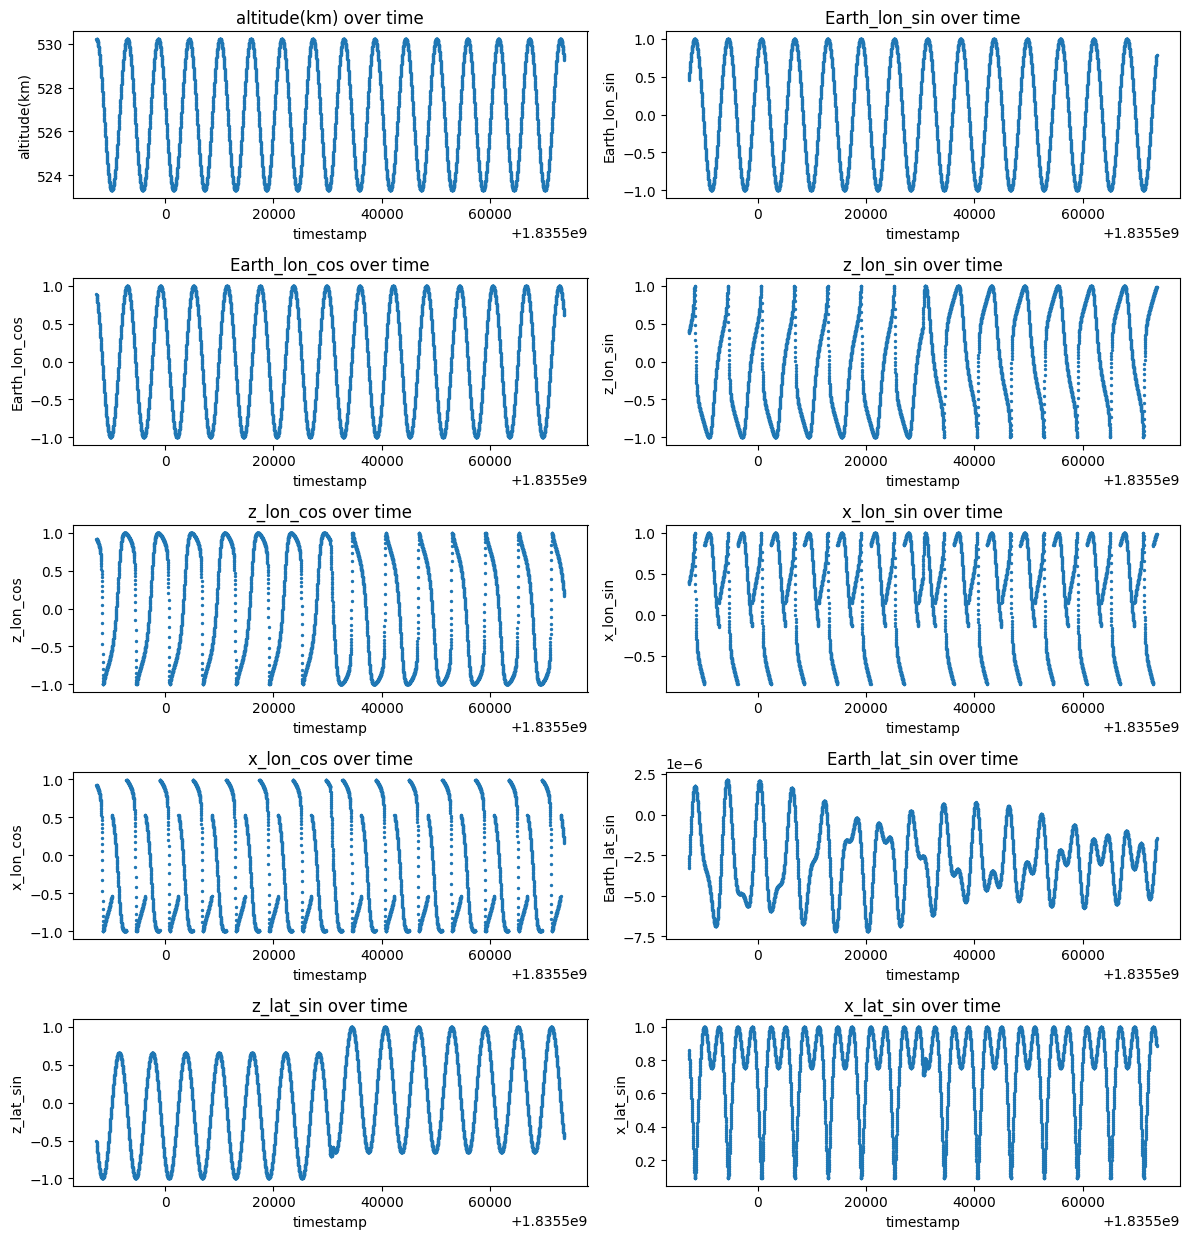

In [127]:
viz_df_cols(satellite_data_15s_ang, n_rows=5, n_cols=2, cols_to_plot=input_features_ang)

> As we can see, now variables like `Earth_lon_sin/cos` show regular periodicity, a complete range [0, 1]

### Timestamps date

In [128]:
satellite_data_original["timestamp"][0]

np.float64(1835487300.0)

In [129]:
# Define desired time res. step
dt = 1  # seconds


n_rows = len(satellite_data_1s_ang)
# Build new timestamps starting at 13:00:00
start_time = pd.Timestamp("2025-01-01 00:00:00") # we choose this date
new_timestamps = start_time + pd.to_timedelta(np.arange(n_rows) * dt, unit="s")
# Assign back
satellite_data_1s_ang["timestamp"] = new_timestamps

# Define desired time res. step
dt = 15  # seconds
n_rows = len(satellite_data_15s_ang)
# Build new timestamps starting at 13:00:00
start_time = pd.Timestamp("2025-01-01 00:00:00") # we choose this date
new_timestamps = start_time + pd.to_timedelta(np.arange(n_rows) * dt, unit="s")
# Assign back
satellite_data_15s_ang["timestamp"] = new_timestamps

# Define desired time res. step
dt = 0.05  # seconds
n_rows = len(satellite_data_50ms_ang)
# Build new timestamps starting at 13:00:00
start_time = pd.Timestamp("2025-01-01 00:00:00") # we choose this date
new_timestamps = start_time + pd.to_timedelta(np.arange(n_rows) * dt, unit="s")
# Assign back
satellite_data_50ms_ang["timestamp"] = new_timestamps

### Visualizing a lightcurve

In [130]:
def viz_lightcurve_all_dets(satellite_df, time_res, interval=(0, 150)):
    start, end = interval

    det_cols = [c for c in satellite_df.columns if c.startswith(target_count_str)]
    n_dets = len(det_cols)

    det_names = [
        "bgo_z1",
        "bgo_z0",
        "bgo_x1",
        "bgo_x0",
        "bgo_y1",
        "bgo_y0",
    ]

    assert n_dets == len(det_names), \
        f"Expected {len(det_names)} detectors, got {n_dets}"

    n_cols = 2
    n_rows = math.ceil(n_dets / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(14, 3 * n_rows),
        sharex=True
    )
    axes = axes.flatten()

    t = satellite_df["timestamp"][start:end]

    for i, (col, det_name) in enumerate(zip(det_cols, det_names)):
        axes[i].step(t, satellite_df[col][start:end])
        axes[i].set_title(det_name)
        axes[i].tick_params(axis="x", labelsize=8)
        axes[i].set_ylabel("Photon counts")
        axes[i].grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"{time_res} binned light curves", fontsize=14)
    plt.tight_layout()
    plt.show()


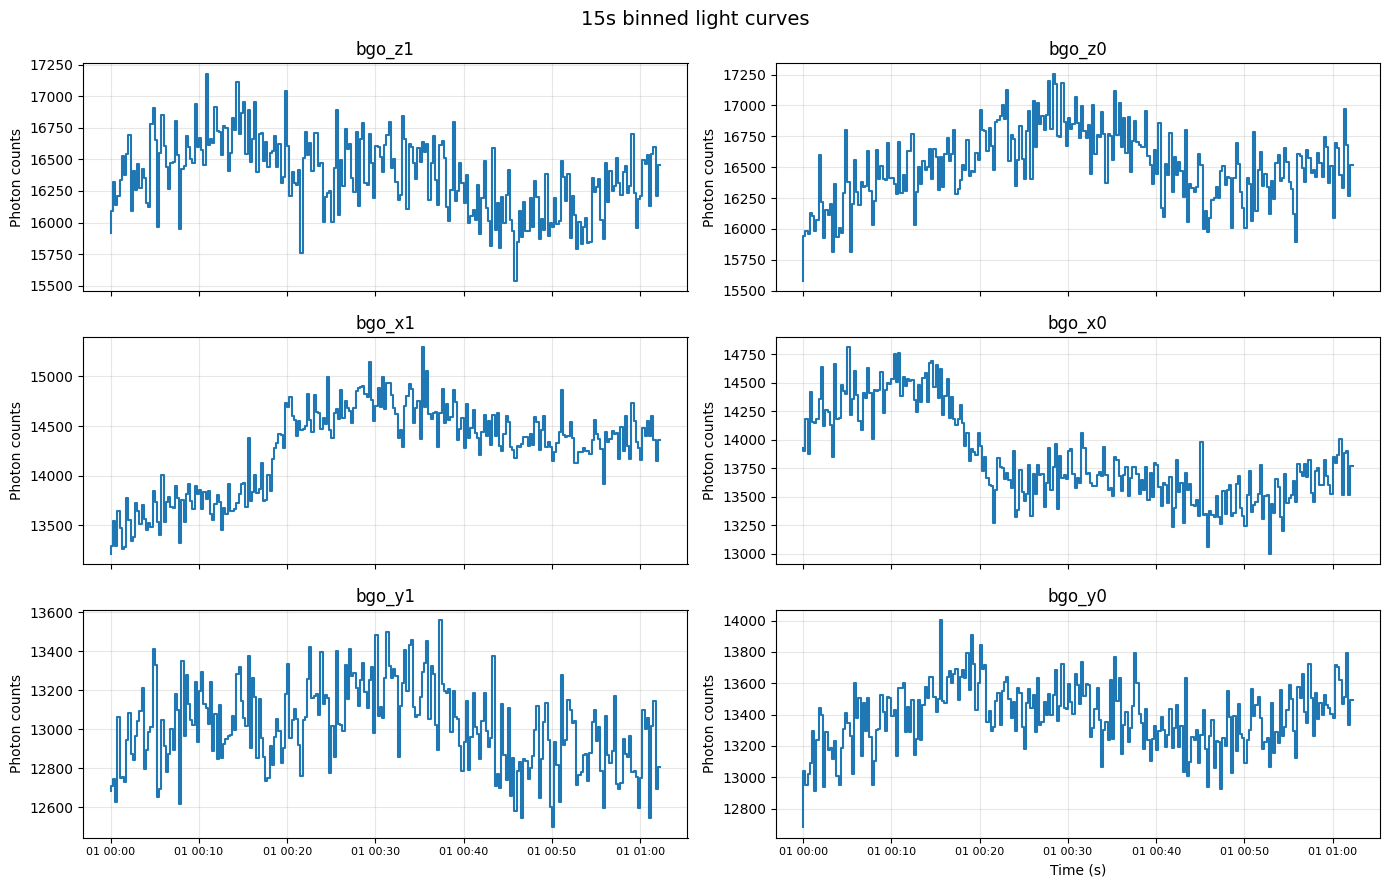

In [131]:
viz_lightcurve_all_dets(satellite_data_15s_ang, "15s", interval=(0, 250))

<a name="countrates"></a>
### Visualizing count rates
Let's plot the count rates for each detector:

In [132]:
print(plt.ylim)

<function ylim at 0x7ce8e8ff71a0>


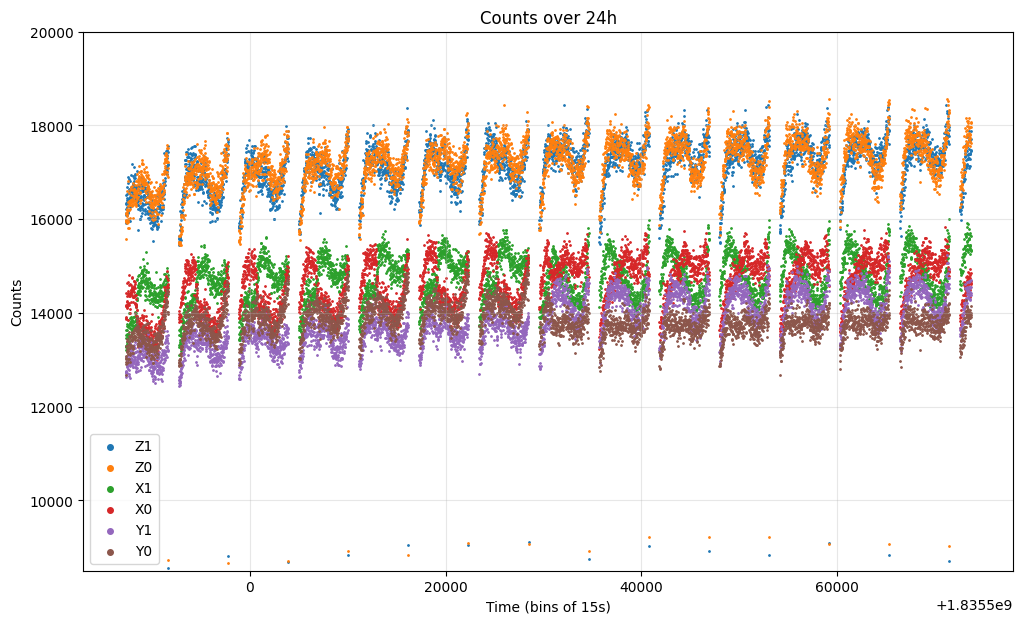

In [133]:
viz_countrates(
    satellite_data_15s,
    total_counts_15s,
    time_res=15,
    count_str="counts_det_",
    title="Counts over 24h",
    y_zoom=(8500, 20000)     # zoom
)

<a name="countrate_hm"></a>
##### Count rates **heatmap**
Let's visualize from a different *p.o.v.* how count rates vary over time for each detector.

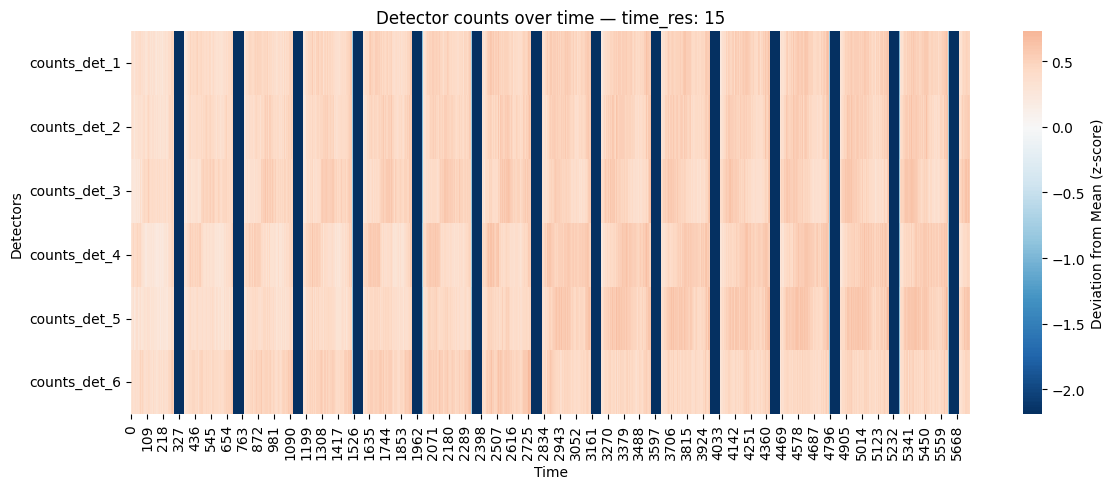

In [134]:
viz_df_heatmap(satellite_data_15s, target_count_str, time_res = "15")

> As we can see, the blanks between count rates in the previous plot correspond to values well below the mean, the **zeros**. Here, we can observe that the early values are slightly below the mean, while the subsequent ones are mostly above it.


> Why are the initial count rates lower than average? In the next section, we’ll find out.

<a name="zeropercissue"></a>
##### **Issue**: zero values percentage

> There are many zeros in our count rate columns. This can be also seen in the heatmap above. They are identical across all detectors, which explains some of the observed periodicity.

In [135]:
zero_count_df_15s = (satellite_data_15s[[f"{target_count_str}{i+1}" for i in range(6)]] == 0).sum()
print(f"Percentage of zeros in each column: {zero_count_df_15s.iloc[0] / satellite_data_15s.shape[0]*100:.1f}%")

Percentage of zeros in each column: 17.1%


In [136]:
zero_count_df_50ms = (satellite_data_50ms[[f"{target_count_str}{i+1}" for i in range(6)]] == 0).sum()
print(f"Percentage of zeros in each column: {zero_count_df_50ms.iloc[0] / satellite_data_50ms.shape[0]*100:.1f}%")

Percentage of zeros in each column: 17.3%


In [137]:
zero_count_df_1s = (satellite_data_1s[[f"{target_count_str}{i+1}" for i in range(6)]] == 0).sum()
print(f"Percentage of zeros in each column: {zero_count_df_1s.iloc[0] / satellite_data_1s.shape[0]*100:.1f}%")

Percentage of zeros in each column: 17.3%


> Indeed, they account for approximately **17%** of each series—a non-negligible proportion.

### A series of **clarifications**

#### 1) Stabilization time
We will only consider data from the second half of the day, starting from the **13th hour**. This is because during the first 12 hours the satellite is still activating, and its emission has not yet reached full intensity.

This behavior can also be observed in the previous [plot](#countrate_hm), where the count rates appear to stabilize around the 13th hour.

Finally, we will convert the timestamp column into a DateTime object to better reflect this temporal structure.

In [138]:
# Selecting the second half of the df
def splitting_data(satellite_df, time_res):
  rocking_time_idx = int(len(satellite_df) / 2)
  satellite_data = satellite_df[rocking_time_idx:].copy().reset_index(drop=True)
  return satellite_data, rocking_time_idx

In [139]:
satellite_data_50ms_split, _ = splitting_data(satellite_data_50ms_ang, 0.05)
satellite_data_1s_split, _ = splitting_data(satellite_data_1s_ang, 1)
satellite_data_15s_split, rocking_time_idx = splitting_data(satellite_data_15s_ang, 15)
print(f"Shapes after splitting: {satellite_data_50ms_split.shape}, {satellite_data_1s_split.shape}, {satellite_data_15s_split.shape}")

satellite_data_50ms_split_raw, _ = splitting_data(satellite_data_50ms, 0.05)
satellite_data_1s_split_raw, _ = splitting_data(satellite_data_1s, 1)
satellite_data_15s_split_raw, rocking_time_idx = splitting_data(satellite_data_15s, 15)
print(f"Shapes after splitting: {satellite_data_50ms_split_raw.shape}, {satellite_data_1s_split_raw.shape}, {satellite_data_15s_split_raw.shape}")

Shapes after splitting: (864000, 17), (43200, 17), (2880, 17)
Shapes after splitting: (864000, 14), (43200, 14), (2880, 14)


In [140]:
display(satellite_data_15s_split.head())

,timestamp,altitude(km),Earth_lon_sin,Earth_lon_cos,z_lon_sin,z_lon_cos,x_lon_sin,x_lon_cos,Earth_lat_sin,z_lat_sin,x_lat_sin,counts_det_1,counts_det_2,counts_det_3,counts_det_4,counts_det_5,counts_det_6
0,2025-01-01 12:00:00,523.598404,0.644155,0.764895,0.458714,0.888584,0.458714,0.888584,-0.000003,-0.671728,0.740798,18009.0,17741.0,14901.0,15124.0,14051.0,14364.0
1,2025-01-01 12:00:15,523.621089,0.655818,0.754919,0.494431,0.869217,0.494431,0.869217,-0.000003,-0.677178,0.735819,17777.0,17368.0,14634.0,15499.0,13952.0,14417.0
2,2025-01-01 12:00:30,523.644631,0.667326,0.744766,0.529122,0.848546,0.529122,0.848546,-0.000003,-0.682074,0.731283,17456.0,17150.0,14744.0,15008.0,14243.0,14327.0
3,2025-01-01 12:00:45,523.669025,0.678678,0.734436,0.562746,0.826630,0.562746,0.826630,-0.000003,-0.686424,0.727201,17316.0,17371.0,14418.0,15152.0,14024.0,13988.0
4,2025-01-01 12:01:00,523.694262,0.689869,0.723934,0.595265,0.803530,0.595265,0.803530,-0.000003,-0.690238,0.723583,17474.0,17347.0,15021.0,15068.0,13649.0,14220.0


###### Inspecting (again) feature distribution

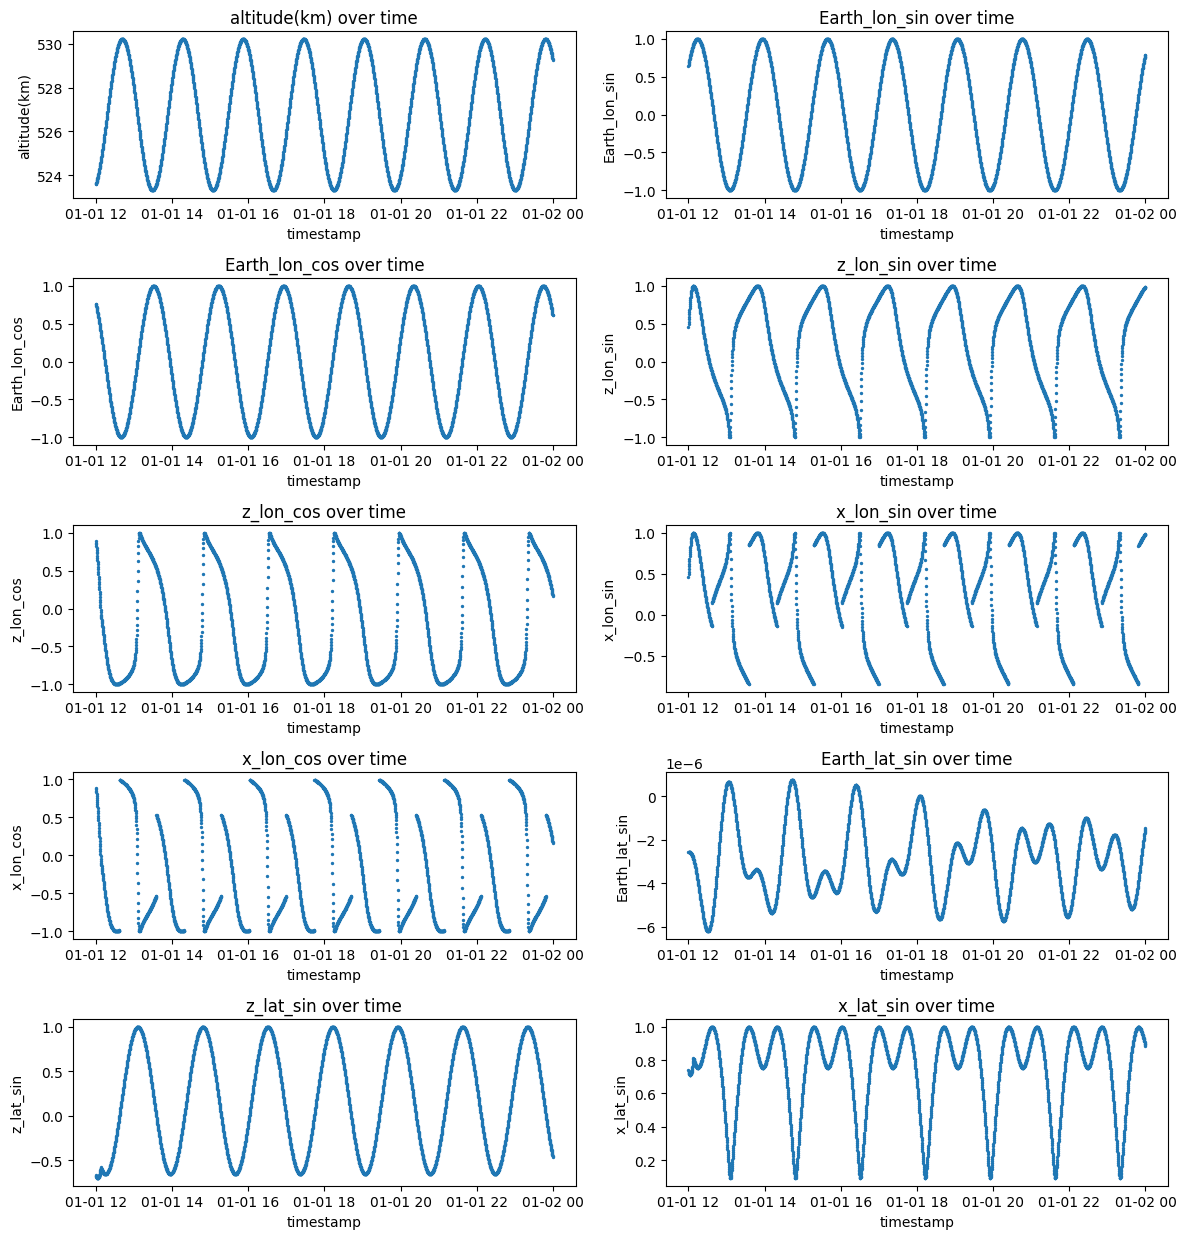

In [141]:
viz_df_cols(satellite_data_15s_split, n_rows=5, n_cols=2, cols_to_plot=input_features_ang)

#### 2) Handling zero values

As spotted [before](#zeropercissue), the dataframe is plenty of zeros. But why is that?


<a name="saa"></a>
###### The South Atlantic Anomaly
> "The South Atlantic Anomaly (SAA) is an area where Earth's inner Van Allen radiation belt comes closest to Earth's surface, dipping down to an altitude of 200 kilometres (120 mi). This leads to an increased flux of energetic particles in this region and exposes orbiting satellites (including the ISS) to higher-than-usual levels of ionizing radiation."
>
> — [Wikipedia](https://en.wikipedia.org/wiki/South_Atlantic_Anomaly)

This means that the satellite is **off** while it transits the SAA. Indeed, the satellite gathers zero count rates in those temporal windows.

Because of that, we can safely delete those rows which contain zero values in their count rates columns.

In [142]:
def remove_zeros(satellite_df):
  zeros_mask = (satellite_df[[f"{target_count_str}{i+1}" for i in range(6)]] == 0).any(axis=1)
  satellite_data_nozeros = satellite_df[~zeros_mask].copy()
  print(f"Number of rows deleted: {satellite_df[zeros_mask].shape[0]}")
  return satellite_data_nozeros

In [143]:
satellite_data_50ms_nozeros = remove_zeros(satellite_data_50ms_split)
satellite_data_1s_nozeros = remove_zeros(satellite_data_1s_split)
satellite_data_15s_nozeros = remove_zeros(satellite_data_15s_split)

print()

satellite_data_50ms_nozeros_raw = remove_zeros(satellite_data_50ms_split_raw)
satellite_data_1s_nozeros_raw = remove_zeros(satellite_data_1s_split_raw)
satellite_data_15s_nozeros_raw = remove_zeros(satellite_data_15s_split_raw)

Number of rows deleted: 148495
Number of rows deleted: 7418
Number of rows deleted: 488

Number of rows deleted: 148495
Number of rows deleted: 7418
Number of rows deleted: 488


In [144]:
threshold_dict = {"15s": 0.4,
                  "1s" : 0.2,
                  "50ms": 0.8}

satellite_nozeros_dict = {
    "15s": satellite_data_15s_nozeros,
    "1s": satellite_data_1s_nozeros,
    "50ms": satellite_data_50ms_nozeros
}

satellite_nozeros_dict_raw = {
    "15s": satellite_data_15s_nozeros_raw,
    "1s": satellite_data_1s_nozeros_raw,
    "50ms": satellite_data_50ms_nozeros_raw
}

def remove_outliers_quantiles(df):
  num_cols = df.select_dtypes(include=np.number).columns
  lower = df[num_cols].quantile(0.004)
  upper = df[num_cols].quantile(0.999)
  mask = ((df[num_cols] >= lower) & (df[num_cols] <= upper)).all(axis=1)
  df_filtered = df[mask]
  return df_filtered

# Q tail filtering — removing the 0.5% of the distribution at its tails
satellite_data_15s_filter_q = remove_outliers_quantiles(satellite_data_15s_nozeros)
satellite_data_1s_filter_q = remove_outliers_quantiles(satellite_data_1s_nozeros)
satellite_data_50ms_filter_q = remove_outliers_quantiles(satellite_data_50ms_nozeros)
print(f"Q-tail — 15s, 1s, 50ms\nNumber of rows deleted: {satellite_data_15s_nozeros.shape[0] - satellite_data_15s_filter_q.shape[0]}")
print(f"Number of rows deleted: {satellite_data_1s_nozeros.shape[0] - satellite_data_1s_filter_q.shape[0]}")
print(f"Number of rows deleted: {satellite_data_50ms_nozeros.shape[0] - satellite_data_50ms_filter_q.shape[0]}")

satellite_data_15s_filter_q_raw = remove_outliers_quantiles(satellite_data_15s_nozeros_raw)
satellite_data_1s_filter_q_raw = remove_outliers_quantiles(satellite_data_1s_nozeros_raw)
satellite_data_50ms_filter_q_raw = remove_outliers_quantiles(satellite_data_50ms_nozeros_raw)

# Update the original dataframes with the modified ones
satellite_data_dict["15s"] = satellite_data_15s_filter_q
satellite_data_dict["1s"] = satellite_data_1s_filter_q
satellite_data_dict["50ms"] = satellite_data_50ms_filter_q

satellite_data_dict_raw["15s"] = satellite_data_15s_filter_q_raw
satellite_data_dict_raw["1s"] = satellite_data_1s_filter_q_raw
satellite_data_dict_raw["50ms"] = satellite_data_50ms_filter_q_raw

Q-tail — 15s, 1s, 50ms
Number of rows deleted: 140
Number of rows deleted: 2334
Number of rows deleted: 47279


---



## **Preparing** to Regression
**Recall**: our goal is to predict the per-bin expected probability distribution of photon counts. The input features woud be the satellite metadata and the output would be a background distribution. The ground truths would be the raw count rates in the dataframe.

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from tf_keras.models import Sequential
from tf_keras.layers import Dense, Input, Conv1D, Activation, Dropout, LayerNormalization, Concatenate
from tf_keras.models import Model
import tensorflow_probability as tfp
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

### Train-Val-Test split

In [146]:
satellite_data_dict["50ms"].head()

,timestamp,altitude(km),Earth_lon_sin,Earth_lon_cos,z_lon_sin,z_lon_cos,x_lon_sin,x_lon_cos,Earth_lat_sin,z_lat_sin,x_lat_sin,counts_det_1,counts_det_2,counts_det_3,counts_det_4,counts_det_5,counts_det_6
0,2025-01-01 12:00:00.000,523.598344,0.644123,0.764922,0.458694,0.888594,0.458694,0.888594,-0.000003,-0.671701,0.740822,44.0,61.0,56.0,38.0,47.0,44.0
1,2025-01-01 12:00:00.050,523.598417,0.644162,0.764889,0.458735,0.888573,0.458735,0.888573,-0.000003,-0.671731,0.740795,36.0,50.0,46.0,58.0,50.0,42.0
2,2025-01-01 12:00:00.100,523.598493,0.644201,0.764856,0.458856,0.888511,0.458856,0.888511,-0.000003,-0.671749,0.740779,68.0,58.0,48.0,55.0,60.0,50.0
3,2025-01-01 12:00:00.150,523.598568,0.644241,0.764823,0.458976,0.888449,0.458976,0.888449,-0.000003,-0.671768,0.740762,75.0,87.0,53.0,68.0,61.0,72.0
4,2025-01-01 12:00:00.200,523.598644,0.644280,0.764790,0.459096,0.888386,0.459096,0.888386,-0.000003,-0.671786,0.740745,71.0,65.0,44.0,56.0,47.0,69.0


In [147]:
#input_features = ["x_lat", "x_lon", "z_lat", "z_lon", "altitude(km)",	"Earth_lat", "Earth_lon"]
input_features = input_features_ang
target_features = [f"{target_count_str}{i+1}" for i in range(6)]

# select time res
df_res = "50ms"
satellite_data = satellite_data_dict[df_res]      # sine/cos encoding
#satellite_data = satellite_data_dict_raw[df_res]   # angular

# --- 1) Define contiguous test size ---
test_fraction = 0.15
viz_fraction = 0.20
n_total = len(satellite_data)
n_contig = int(n_total * test_fraction)
n_contig_viz = int(n_total * viz_fraction)

# --- 2) Extract contiguous test (LAST 10%) ---
X_test_contig = satellite_data[input_features].iloc[-n_contig:]
y_test_contig = satellite_data[target_features].iloc[-n_contig:]

# --- 2) Extract contiguous data for viz 50ms (LAST 15%)
X_test_viz = satellite_data[input_features].iloc[-n_contig_viz:]
y_test_viz = satellite_data[target_features].iloc[-n_contig_viz:]

# --- 3) Remove contiguous block from the dataset ---
X_remaining = satellite_data[input_features].iloc[:-n_contig]
y_remaining = satellite_data[target_features].iloc[:-n_contig]

# --- 4) IID split only on the remaining data ---
X_train, X_test, y_train, y_test = train_test_split(
    X_remaining,
    y_remaining,
    test_size=0.10,
    random_state=42,
    shuffle=True
)
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("X_test_contig", X_test_contig.shape)
print("y_test_contig", y_test_contig.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (511193, 10)
X_test (56800, 10)
X_test_contig (100233, 10)
y_test_contig (100233, 6)
y_train (511193, 6)
y_test (56800, 6)


### Normalizing input features
Crucial step in a Machine Learning process. In this case, it is even more important, since the metadata features lie in a excessively big scale (~$1e^{16}$).

In [148]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



---



## **Collinearity** issue
SHAP can share feature importance between strongly **correlated** pairs of features. We try to fix collinearity with the **residual** trick:
1. choose the main feature $F$ in a pair $(F, G)$
2. fit a model such that $G ≈ h(F)$
3. substitute G with the residual $R = G - h(F)$

$R$ will now contain just the info of $G$ that are not explainable by $F$.

*(It is just a try, it isn't meant to work).*

In [152]:
from sklearn.linear_model import LinearRegression

def residual_trick_multi(main_fs, secondary_f, train_ds, test_ds=None, drop_original=True):
    train_res = train_ds.copy()

    X = train_res[main_fs]
    y = train_res[secondary_f]

    reg = LinearRegression().fit(X, y)

    print(f"{secondary_f} ~ {main_fs}")
    print("R^2:", reg.score(X, y))
    print("coef:", reg.coef_)
    print("intercept:", reg.intercept_)

    train_res[f"{secondary_f}_res"] = y - reg.predict(X)

    if drop_original:
        train_res = train_res.drop(columns=[secondary_f])

    if test_ds is not None:
        test_res = test_ds.copy()
        test_res[f"{secondary_f}_res"] = test_res[secondary_f] - reg.predict(test_res[main_fs])

        if drop_original:
            test_res = test_res.drop(columns=[secondary_f])

        return train_res, test_res, reg

    return train_res, reg

In [153]:
X_train_res, X_test_res, reg_zlat = residual_trick_multi(
    main_fs=["Earth_lon_sin", "Earth_lon_cos"],
    secondary_f="z_lat_sin",
    train_ds=X_train,
    test_ds=X_test
)
print()
X_train_res, X_test_res, reg_zlon_sin = residual_trick_multi(
    main_fs=["Earth_lon_sin", "Earth_lon_cos"],
    secondary_f="z_lon_sin",
    train_ds=X_train_res,
    test_ds=X_test_res
)
print()
X_train_res, X_test_res, reg_zlon_cos = residual_trick_multi(
    main_fs=["Earth_lon_sin", "Earth_lon_cos"],
    secondary_f="z_lon_cos",
    train_ds=X_train_res,
    test_ds=X_test_res
)

X_train_res[["z_lat_sin_res","Earth_lon_sin","Earth_lon_cos"]].corr()

z_lat_sin ~ ['Earth_lon_sin', 'Earth_lon_cos']
R^2: 0.9951803215586119
coef: [-0.82409282  0.03481974]
intercept: 0.1673177839286819

z_lon_sin ~ ['Earth_lon_sin', 'Earth_lon_cos']
R^2: 0.9498970897139338
coef: [0.63892238 0.47906133]
intercept: 0.20280140357829268

z_lon_cos ~ ['Earth_lon_sin', 'Earth_lon_cos']
R^2: 0.8828948160445107
coef: [-0.16523365  0.87610107]
intercept: -0.2468793438824566


,z_lat_sin_res,Earth_lon_sin,Earth_lon_cos
z_lat_sin_res,1.000000e+00,-2.664734e-15,-1.453958e-15
Earth_lon_sin,-2.664734e-15,1.000000e+00,2.315272e-01
Earth_lon_cos,-1.453958e-15,2.315272e-01,1.000000e+00


In [154]:
#@title Preparing the terrain
scaler_res = StandardScaler()
X_train_res_scaled = scaler_res.fit_transform(X_train_res)
X_test_res_scaled = scaler_res.transform(X_test_res)

feature_names_res = list(X_train_res.columns)
print(feature_names_res)

['altitude(km)', 'Earth_lon_sin', 'Earth_lon_cos', 'x_lon_sin', 'x_lon_cos', 'Earth_lat_sin', 'x_lat_sin', 'z_lat_sin_res', 'z_lon_sin_res', 'z_lon_cos_res']


## **Kolmogorov-Arnold** Regressor

In [149]:
import torch
!pip install pykan
from kan import *

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 4.8 MB/s eta 0:00:00


In [ ]:
# load model
ckpt_path = './model/0.3'
model_kan = KAN.loadckpt(ckpt_path)

In [ ]:
# Ensure the directory for storing history files exists
history_dir = './model'
os.makedirs(history_dir, exist_ok=True)

### Training

In [ ]:
# select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# numpy -> float32
X_train_np = np.asarray(X_train_res_scaled, dtype=np.float32)
y_train_np = np.asarray(y_train, dtype=np.float32)
X_test_np  = np.asarray(X_test_res_scaled, dtype=np.float32)
y_test_np  = np.asarray(y_test, dtype=np.float32)

# y must be (N, 6)
# print shapes to be sure
print("X:", X_train_np.shape, "y:", y_train_np.shape)

# tensors on SAME device
X_train_t = torch.as_tensor(X_train_np, device=device)
y_train_t = torch.as_tensor(y_train_np, device=device)
X_test_t  = torch.as_tensor(X_test_np,  device=device)
y_test_t  = torch.as_tensor(y_test_np,  device=device)

dataset = {
    "train_input": X_train_t,
    "train_label": y_train_t,
    "test_input":  X_test_t,
    "test_label":  y_test_t
}

In [ ]:
print("Feature order:")
for i, f in enumerate(feature_names_res):
    print(f"x_{i:02d} -> {f}")

In [ ]:
# create a KAN: 7D inputs, 6 outputs, and H hidden neurons, cubic spline (k=3), grid intervals (grid=5).
model_kan = KAN(
            width=[len(input_features), 10, 6],  # input → output, no hidden layer
            grid=5,                              # number of spline grid intervals
            k=3,                                 # spline order (cubic) (try 4)
            device="cuda",
            seed=42
        )

In [ ]:
# plot
model_kan(dataset["train_input"])

In [ ]:
# fit model
history_kan = model_kan.fit(dataset, opt="Adam", lr=1e-3, steps=6000, lamb=5e-6)
model_kan.plot(scale = 5)

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_kan["train_loss"], label="loss")
plt.legend()
plt.show()

> The learned connectivity pattern reflects the structure of the problem: most of the complexity is concentrated in the univariate transformations from inputs to hidden units, while the output layer acts mainly as a weak aggregator.

> This indicates that the deterministic component of the background is captured at the level of input-dependent functional responses, whereas the overall signal is largely dominated by stochastic fluctuations. As a result, the model avoids introducing unnecessary nonlinearities at the output level, preventing overfitting and improving interpretability.

>> **Note**: the deterministic component is the small, structured part of the background that consistently depends on physical and geometric variables, while the stochastic component represents unpredictable fluctuations that dominate the signal. The KAN isolates the former without fitting the latter.

#### Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
def eval_kan(model, dataset):
  model.eval()
  with torch.no_grad():
      y_pred_t = model(dataset["test_input"])   # shape: (N, out_dim)
  y_pred = y_pred_t.detach().cpu().numpy()
  y_true = dataset["test_label"].detach().cpu().numpy()
  return y_pred, y_true

In [ ]:
y_pred, y_true = eval_kan(model_kan, dataset)
print(y_pred.shape, y_true.shape)

In [ ]:
def get_metrics(y_true, y_pred):
  mae_per = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
  rmse_per = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='raw_values'))
  r2_per = r2_score(y_true, y_pred, multioutput='raw_values')
  perc_error = np.mean(np.abs(y_test - y_pred) / y_test)

  print(f"Percentage error: {perc_error*100:.2f}%")
  for i in range(y_true.shape[1]):
      print(f"detector {i}: MAE={mae_per[i]:.4f}, RMSE={rmse_per[i]:.4f}, R2={r2_per[i]:.4f}")
  return mae_per, rmse_per, r2_per, perc_error

mae_per, rmse_per, r2_per, perc_error = get_metrics(y_true, y_pred)


> Again, a low R2 means that the total variance is dominated by noise!
>
> Despite this, the results are aligned with the probabilistic baselines.

#### Pruning model

In [ ]:
# default: 0.03 for edge_th, 0.01 for node_th
pruned_model = model_kan.prune(edge_th=0.02, node_th=0.01)
pruned_model.plot(scale=2)

<a name="kanplot"></a>
> As we can see, the model has pruned the less contributing edges, while the most influential are the bold ones.

We have to fine-tune the model because we "shocked" the model a bit, hence we need to "stabilize" the model (its edges and nodes).

In [ ]:
hist_p = pruned_model.fit(dataset, opt="Adam", lr=1e-3, steps=4000, lamb=5e-4)
# or: lr=1e-4 if it’s unstable

In [ ]:
y_pred, y_true = eval_kan(pruned_model, dataset)
mae_per, rmse_per, r2_per, perc_error = get_metrics(y_true, y_pred)

> We achieve better results! This is because pruning acts as **regularization**.

In [ ]:
model_kan.plot(scale=10)

##### Evaluation

In [ ]:
X_test_contig_res = X_test_contig.copy()

X_test_contig_res, _, reg_zlat = residual_trick_multi(
    main_fs=["Earth_lon_sin", "Earth_lon_cos"],
    secondary_f="z_lat_sin",
    train_ds=X_test_contig_res,
    test_ds=X_test_contig_res
)

print()

X_test_contig_res, _, reg_zlon_sin = residual_trick_multi(
    main_fs=["Earth_lon_sin", "Earth_lon_cos"],
    secondary_f="z_lon_sin",
    train_ds=X_test_contig_res,
    test_ds=X_test_contig_res
)

print()

X_test_contig_res, _, reg_zlon_cos = residual_trick_multi(
    main_fs=["Earth_lon_sin", "Earth_lon_cos"],
    secondary_f="z_lon_cos",
    train_ds=X_test_contig_res,
    test_ds=X_test_contig_res
)

In [ ]:
# scale
X_test_contig_res_scaled = scaler_res.transform(X_test_contig_res)

In [ ]:
def plot_kan_lightcurve_with_empirical_band(
    model,
    dataset,
    det_idx=1,              # 1-based
    start=0,
    end = 50,
    bin_duration=1.0,
    k=1.0,
    use_local_residual_std=False,
    local_std_window=200,
    title_prefix="KAN Regressor",
    det_names=None
):
    """
    Plot true counts vs predicted mean background for one detector in a selected contiguous test window.

    The uncertainty band is empirical, estimated from residuals on the selected
    test set contained in `dataset`. It is NOT a true probabilistic interval.

    dataset must contain:
        - dataset["test_input"] : torch.Tensor of shape (N, n_features)
        - dataset["test_label"] : torch.Tensor of shape (N, n_outputs)
    """

    det = det_idx - 1  # 0-based detector index

    X_full = dataset["test_input"]
    y_full = dataset["test_label"]

    n_samples = X_full.shape[0]

    if start >= end:
        raise ValueError("Invalid window: start must be smaller than end.")

    # Build windowed dataset
    dataset_window = {
        "test_input": X_full[start:end],
        "test_label": y_full[start:end]
    }


    # Predict only on selected window
    y_pred_window_all, y_true_window_all = eval_kan(model, dataset_window)

    # Extract selected detector
    y_window = y_true_window_all[:, det]
    y_pred_window = y_pred_window_all[:, det]

    bins = np.arange(start, end) * bin_duration

    # Metrics on window
    mae = mean_absolute_error(y_window, y_pred_window)
    rmse = np.sqrt(mean_squared_error(y_window, y_pred_window))

    # For empirical residual std, use full test set or local neighborhood
    # Here we compute full-test residuals from the WHOLE dataset for a more stable estimate
    y_pred_full_all, y_true_full_all = eval_kan(model, dataset)
    y_true_det_full = y_true_full_all[:, det]
    y_pred_det_full = y_pred_full_all[:, det]
    residuals_full = y_true_det_full - y_pred_det_full

    if use_local_residual_std:
        sigma_window = []
        half_w = local_std_window // 2

        for i in range(start, end):
            lo = max(0, i - half_w)
            hi = min(n_samples, i + half_w + 1)
            sigma_i = np.std(residuals_full[lo:hi], ddof=1) if (hi - lo) > 1 else 0.0
            sigma_window.append(sigma_i)

        sigma_window = np.array(sigma_window)
    else:
        sigma_global = np.std(residuals_full, ddof=1)
        sigma_window = np.full_like(y_pred_window, sigma_global, dtype=float)

    # Empirical band
    lower = y_pred_window - k * sigma_window
    upper = y_pred_window + k * sigma_window

    # Coverage
    inside = (y_window >= lower) & (y_window <= upper)
    coverage = 100 * np.mean(inside)

    # Detector name
    if det_names is not None:
        detector_name = det_names.get(f"det_{det_idx}", f"{det_idx}")
    else:
        detector_name = str(det_idx)

    # Plot
    plt.figure(figsize=(15, 4))

    plt.step(
        bins, y_window, where="mid",
        label="True counts", linewidth=1.5
    )

    plt.step(
        bins, y_pred_window, where="mid",
        linestyle="--", linewidth=1.8,
        label="Predicted mean background",
        color="blue"
    )

    plt.fill_between(
        bins, lower, upper,
        alpha=0.25,
        label=f"Empirical ±{k}σ residual band",
        color="orange",
        zorder = 3
    )

    band_type = "local residual std" if use_local_residual_std else "global residual std"

    plt.title(
        f"{title_prefix}\n"
        f"Detector {detector_name} — Test window [{start}:{end}] | "
        f"MAE={mae:.2f}, RMSE={rmse:.2f}, Coverage={coverage:.1f}%\n"
        f"Band based on {band_type}"
    )
    plt.xlabel("Time (s))")
    plt.ylabel("Counts")
    plt.grid(alpha=0.3, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Window MAE: {mae:.3f}")
    print(f"Window RMSE: {rmse:.3f}")
    print(f"Fraction of true counts within empirical ±{k}σ band: {coverage:.2f}%")

In [ ]:
device = next(pruned_model.parameters()).device

dataset_contig = {
    "test_input": torch.tensor(X_test_contig_res_scaled, dtype=torch.float32, device=device),
    "test_label": torch.tensor(y_test_contig.values, dtype=torch.float32, device=device)
}

plot_kan_lightcurve_with_empirical_band(
    model=pruned_model,
    dataset=dataset_contig,
    det_idx=4,
    start=0,
    end=3920,
    bin_duration=1,
    k=3,
    use_local_residual_std=False,
    det_names=det_names
)

### Interpretability
We start by **freezing** each learned spline converting it into a **symbolic** base functions. This is actually an **approximation**, that is done to make the model more interpretable. We use symbolic functions instead of splines because splines are challenging to interpret, intrinsecally being complex mathematical objects. In order to do that, we compute a **local** [symbolic regression](https://en.wikipedia.org/wiki/Symbolic_regression), estimating affine parameters and choosing the function that maximizes the R2 score.
What we actually get will be functions of our input features!   

In [ ]:
# Freezing each spline and converts it to a symbolic piecewise polynomial representation
lib = ['x','x^2','x^3','x^4','x^5','exp','log','sqrt','tanh','sin','cos','abs']

# Ensure the directory for storing history files exists
history_dir = './model'
os.makedirs(history_dir, exist_ok=True)

pruned_model.auto_symbolic(lib=lib) # [layer, input, output]

> Interpretation of: `fixing (1,2,0) with x, r2=1.0000003576, c=1`
>
>> - KAN found that spline = perfect identity function, such that it replaced it with `f(x) = x`
>>
>> - R² ~ 1 proves it’s an exact linear mapping
>>
>> - `c = 1` indicates the constant term of the linear fit
>
> This seems good: it makes the network simpler and more interpretable.

In [ ]:
pruned_model.symbolic_formula()[::][1] # print the input features (first layer)

In [ ]:
symbol_kan.plot(scale=10)

> this shows the activations of the hidden layer, that, due to pruning, just correspond to input features (?)

In [ ]:
pruned_model.symbolic_formula()[0][1]# print the symbolic formula of the second output (det)

As a result, we obtain a fully symbolic and analytical function that describes how the background
signal of each detector can be computed from the input features. For the first detector, the learned
symbolic model is:

\
\begin{aligned}
f_{\text{det}_1}(X)
=&\; 10.5303\,x_1
+ 0.9601\,x_2
+ 2.0749\,x_3
+ 6.8693\,x_4
+ 6.4498\,x_5
+ 3.2176\,x_6
- 1.3958\,x_7 \\
&\; -\, 0.00409\,\exp(5.8841\, x_5) -\, 11.9787\, \sin(1.6879\, x_7 - 3.7998) \\
&\; -\, 4.2900\, \sin(1.9612\, x_7 + 5.6056)
+\; 1160.8918 .
\end{aligned}


In [ ]:
for d in range(6):
  print(pruned_model.symbolic_formula()[0][d]) # print the symbolic formula of all dets

After symbolifying all the activation functions in the network, the only
remaining parameters are the affine parameters. We continue training these affine parameters.

In [ ]:
pruned_model_2 = pruned_model
pruned_model_2.fit(dataset, opt="Adam", lr=1e-3, steps=500, lamb=5e-6)

#### Feature attribution

In [ ]:
pruned_model_2 = pruned_model

Inspecting how each kind of neuron (of each layer) depends on each input feature. These results will show in a clearer way what the plotted model with its weighted edges showed us [before](#kanplot).

The function `attribute(l, n)` gives us the symbolic dependence of the *(l,n)-th* neuron on each input feature. In other words, it tells us which input features influence that neuron, and how strongly.

In [ ]:
input_features = feature_names_res
print(input_features)

In [ ]:
pruned_model_2.feature_names = list(input_features)

In [ ]:
# the n-th neuron in the l-th layer
# - the input layer has 7 inputs (features)
# - the hidden layer has 20 neurons
# - the output layer has 6 outputs (detectors)

# e.g.
l = 1 # layer
n = 4 # neuron
pruned_model_2.attribute(l, n)

In [ ]:
# inspecting input layer (naive)
for d in range(7):
  pruned_model_2.attribute(0, d)

> As expected, each feature depends on its own in the input layer

In [ ]:
# inspecting how hidden nodes depend on input features
for d in range(10):
  pruned_model_2.attribute(1, d)

In [ ]:
# inspecting output layer
for d in range(6):
  pruned_model_2.attribute(2, d)

other things

In [ ]:
def get_input_hidden_matrix(model, n_hidden=10):
    rows = []
    for h in range(n_hidden):
        A = model.attribute(1, h)
        if hasattr(A, "detach"):
            A = A.detach().cpu().numpy()
        rows.append(A)
    return np.stack(rows, axis=0)

input_hidden = get_input_hidden_matrix(pruned_model_2)
print(input_hidden.shape)

In [ ]:
hidden_names = [f"h{i}" for i in range(10)]

input_hidden_df = pd.DataFrame(
    input_hidden,
    index=hidden_names,
    columns=feature_names_res
)

plt.figure(figsize=(12,6))

sns.heatmap(
    input_hidden_df,
    annot=True,
    fmt=".3f",
    cmap="crest"
)

plt.title("Input → hidden attribution")
plt.xlabel("Input features")
plt.ylabel("Hidden neurons")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
mean_feature_importance = np.mean(np.abs(input_hidden), axis=0)

feat_imp_series = pd.Series(
    mean_feature_importance,
    index=feature_names_res
).sort_values(ascending=False)

plt.figure(figsize=(9,4))

feat_imp_series.plot(kind="bar")

plt.ylabel("Mean absolute attribution")
plt.title("Mean feature importance across hidden neurons")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()
print(feat_imp_series)

hidden -> output

In [ ]:
def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.array(x)

def get_hidden_output_attributions(model, n_outputs=6):
    rows = []
    for d in range(n_outputs):
        A = to_numpy(model.attribute(2, d))
        assert A.ndim == 1, f"Expected 1D vector, got {A.shape}"
        rows.append(A)
    return np.stack(rows, axis=0)   # shape: (n_outputs, n_hidden)

hidden_out_contrib = get_hidden_output_attributions(pruned_model_2, n_outputs=6)
print(hidden_out_contrib.shape)   # (6, 10)
print(hidden_out_contrib)

In [ ]:
detector_names = [f"{det_names[f"det_{i+1}"]}" for i in range(6)]
hidden_names = [f"h{i}" for i in range(10)]

hidden_out_df = pd.DataFrame(
    hidden_out_contrib,
    index=detector_names,
    columns=hidden_names
)

plt.figure(figsize=(12, 6))
sns.heatmap(hidden_out_df, annot=True, fmt=".3f", cmap="magma")
plt.title("Hidden → output contribution per detector")
plt.xlabel("Hidden neurons")
plt.ylabel("Detectors")
plt.tight_layout()
plt.show()

In [ ]:
detector_corr = hidden_out_df.T.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(detector_corr, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="coolwarm")
plt.title("Detector similarity from hidden → output contributions")
plt.tight_layout()
plt.show()

print(detector_corr)

In [ ]:
hidden_importance_global = hidden_out_df.mean(axis=0).sort_values(ascending=False)

plt.figure(figsize=(8, 3.5))
hidden_importance_global.plot(kind="bar")
plt.title("Global hidden neuron importance (mean across detectors)")
plt.ylabel("Mean hidden → output attribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(hidden_importance_global)

input -> hidden -> global

In [ ]:
combined_importance = np.zeros(10)

for d in range(6):
    for j in range(10):
        combined_importance += abs(hidden_out_contrib[d,j]) * abs(input_hidden[j])

combined_importance /= combined_importance.sum() # normalization
combined_series = pd.Series(
    combined_importance,
    index=feature_names_res
).sort_values(ascending=False)
plt.figure(figsize=(9,4))

sns.barplot(
    x=combined_series.index,
    y=combined_series.values,
    color="steelblue"
)

plt.ylabel("Normalized importance")
plt.title("Global feature importance (KAN attribution)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()